0 1.6171944737434387 0.5676236152648926
20 0.6906821876764297 1.3138245344161987
40 0.8331309258937836 1.1221897602081299
60 0.40990977734327316 1.3292642831802368
80 0.29748609848320484 1.409627914428711
100 0.33392950147390366 1.3962939977645874
120 0.2730235569179058 1.7889316082000732
140 0.14672327786684036 1.6323823928833008
160 0.09731543436646461 1.954176425933838
180 0.10268672648817301 2.0199151039123535


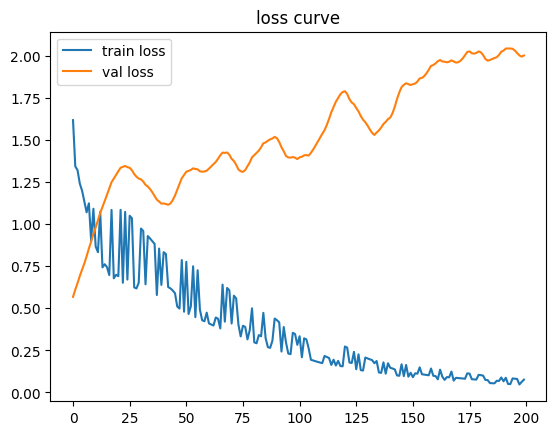

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset,DataLoader,random_split
import matplotlib.pyplot as plt
X=torch.tensor([
    [1,2],
    [2,1],
    [3,4],
    [4,3]
],dtype=torch.float32)
Y=torch.tensor([
    [0.0],
    [0.0],
    [1.0],
    [1.0]
])
dataset=TensorDataset(X,Y)
train_size=int(0.75*len(dataset))
val_size=len(dataset)-train_size
train_dataset,val_dataset=random_split(dataset,[train_size,val_size])
train_loader=DataLoader(train_dataset,batch_size=2,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=2)
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(2,4)
        self.fc2=nn.Linear(4,1)
    def forward(self,X):
        X=self.fc1(X)
        X=torch.relu(X)
        X=self.fc2(X)
        return X
model=Net()
criterion=nn.BCEWithLogitsLoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)
epochs=200
train_losses=[]
val_losses=[]
for epoch in range(epochs):
    model.train()
    train_loss=0
    for X_batch,Y_batch in train_loader:
        pred=model(X_batch)
        loss=criterion(pred,Y_batch)
        optimizer.zero_grad()#清空舊梯度
        loss.backward()#計算新梯度
        optimizer.step()#更新參數
        train_loss+=loss.item()
    model.eval()
    val_loss=0
    with torch.no_grad():
        for X_val,Y_val in val_loader:
            pred=model(X_val)
            loss=criterion(pred,Y_val)
            val_loss+=loss.item()
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch % 20 == 0:
        print(epoch,train_loss,val_loss)

plt.plot(train_losses,label="train loss")
plt.plot(val_losses,label="val loss")
plt.legend()
plt.title("loss curve")
plt.show()
